In [6]:
from neurotools.modules import ElegantReverb
from neurotools.models import ElegantReverbNetwork
import numpy as np
import torch
from matplotlib import pyplot as plt

In [27]:
adj = torch.zeros((4, 4))
adj[:, 2] = 1
adj[2, :] = 1
rnet = ElegantReverbNetwork(num_nodes=4, node_shape=(1, 3, 5, 5), kernel_size=4, edge_module=ElegantReverb, track_activation_history=True, mask=adj)

Using kernel 3  and pad 1


In [8]:
for i in range(1000):
    rnet()

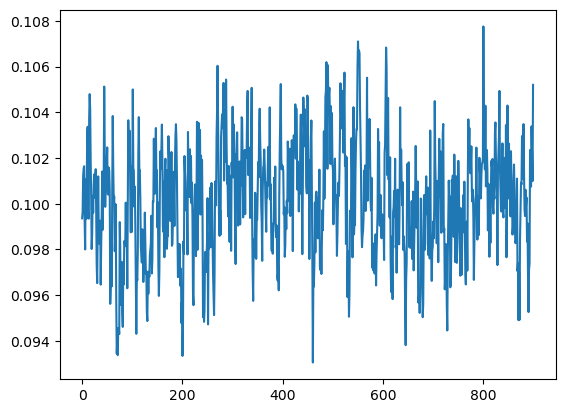

In [16]:
history = rnet.past_states
history = np.array([s.detach().squeeze().numpy() for s in history])
plt.plot(history[100:, 1, 0, 1, 2])

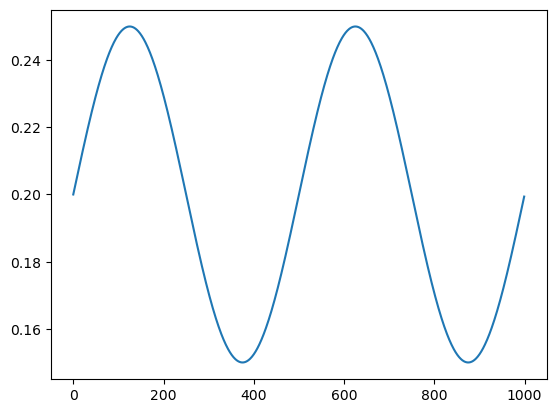

In [28]:
x = torch.arange(0, 1000)
target_pattern = .05 * torch.sin((x * 4 * torch.pi) / 1000) + .2
plt.plot(target_pattern)

In [39]:
optim = torch.optim.Adam(params=rnet.parameters(), lr=.001)
for gen in range(1000):
    rnet.past_states = []
    rnet = rnet.detach(reset_intrinsic=True)
    optim.zero_grad()
    for i in range(1000):
        rnet()
    history = torch.stack(rnet.past_states)
    node_history = history[:, 2, 0, 0, 0].squeeze()
    loss = torch.sqrt(torch.sum((target_pattern - node_history) ** 2))
    print("gen", gen, "loss", loss)
    loss.backward()
    optim.step()

gen 0 loss tensor(1.3460, grad_fn=<SqrtBackward0>)
gen 1 loss tensor(1.4128, grad_fn=<SqrtBackward0>)
gen 2 loss tensor(1.3412, grad_fn=<SqrtBackward0>)
gen 3 loss tensor(1.3089, grad_fn=<SqrtBackward0>)
gen 4 loss tensor(1.3264, grad_fn=<SqrtBackward0>)
gen 5 loss tensor(1.3495, grad_fn=<SqrtBackward0>)
gen 6 loss tensor(1.2890, grad_fn=<SqrtBackward0>)
gen 7 loss tensor(1.3022, grad_fn=<SqrtBackward0>)
gen 8 loss tensor(1.2778, grad_fn=<SqrtBackward0>)
gen 9 loss tensor(1.2552, grad_fn=<SqrtBackward0>)
gen 10 loss tensor(1.2664, grad_fn=<SqrtBackward0>)
gen 11 loss tensor(1.2303, grad_fn=<SqrtBackward0>)
gen 12 loss tensor(1.2583, grad_fn=<SqrtBackward0>)
gen 13 loss tensor(1.2638, grad_fn=<SqrtBackward0>)
gen 14 loss tensor(1.2212, grad_fn=<SqrtBackward0>)
gen 15 loss tensor(1.2558, grad_fn=<SqrtBackward0>)
gen 16 loss tensor(1.2242, grad_fn=<SqrtBackward0>)
gen 17 loss tensor(1.2316, grad_fn=<SqrtBackward0>)
gen 18 loss tensor(1.2159, grad_fn=<SqrtBackward0>)
gen 19 loss tensor(1.2

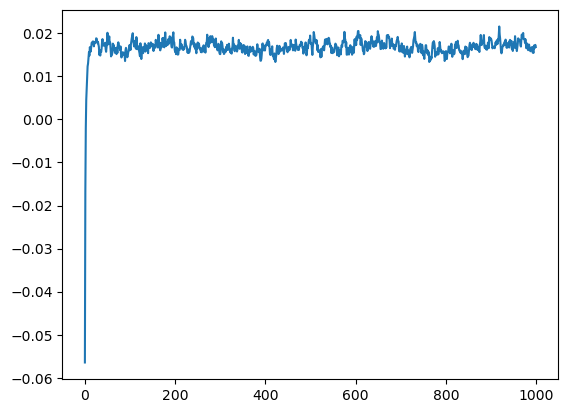

In [45]:
plt.plot(history[0:, 2, 0, 0, 0].detach().numpy())